# Box Counting on the FC Barcelona Crest

This notebook uses the image `barca crest.png` and applies the **box-counting algorithm** to estimate its effective dimensionality.

We will look at two versions of the image:
- a **foreground mask** for the crest itself
- an **edge map** that emphasizes the boundary structure

The box-counting dimension is estimated from a log-log fit of the number of occupied boxes versus box size.

In [20]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageFilter

plt.rcParams['figure.figsize'] = (7, 6)
plt.rcParams['image.cmap'] = 'gray'

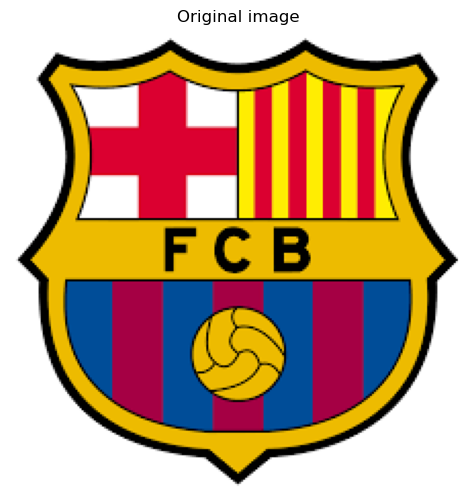

In [21]:
# Load the image from the workspace root
image_path = Path('/Users/joshuaclavecillas/anaconda_projects/barca crest.png')
if not image_path.exists():
    raise FileNotFoundError(f'Could not find image: {image_path}')

img = Image.open(image_path).convert('RGB')
rgb = np.array(img)

# Show the original image
fig, ax = plt.subplots()
ax.imshow(rgb)
ax.set_title('Original image')
ax.axis('off')
plt.show()

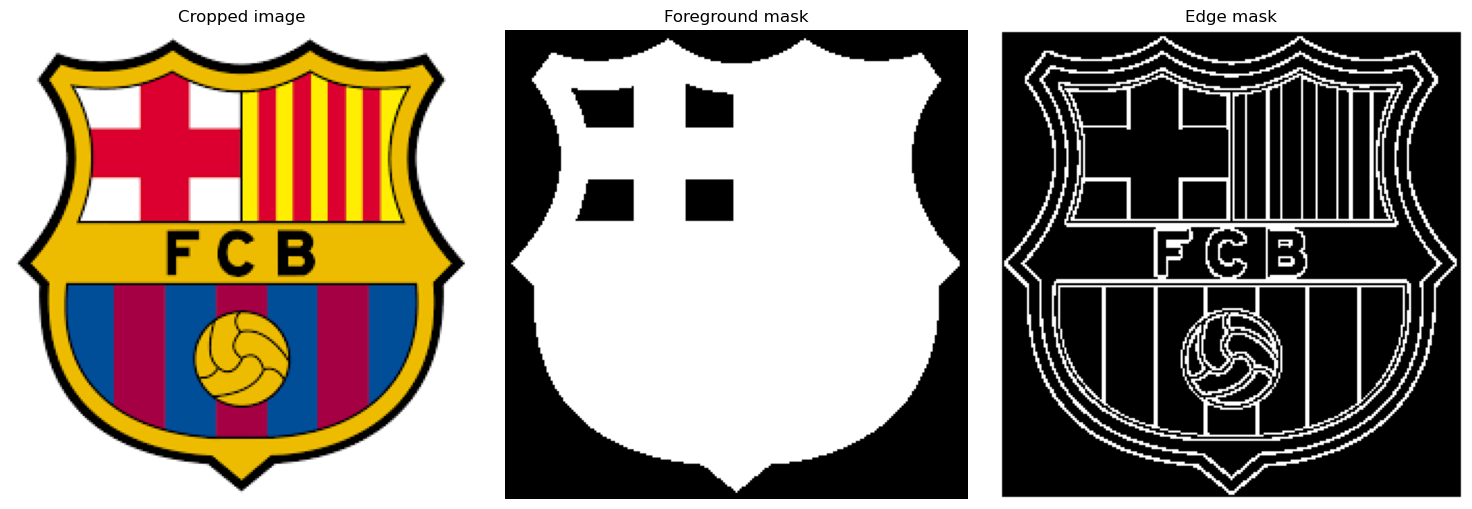

In [26]:
# Build a foreground mask by excluding near-white background pixels
# This works well for the crest because the background is mostly white.
threshold = 245
foreground = np.any(rgb < threshold, axis=2)

# Crop to the bounding box of the foreground to avoid counting empty background
ys, xs = np.where(foreground)
y0, y1 = ys.min(), ys.max() + 1
x0, x1 = xs.min(), xs.max() + 1
pad = 8
y0 = max(0, y0 - pad)
x0 = max(0, x0 - pad)
y1 = min(foreground.shape[0], y1 + pad)
x1 = min(foreground.shape[1], x1 + pad)

foreground_crop = foreground[y0:y1, x0:x1]
rgb_crop = rgb[y0:y1, x0:x1]

# Create an edge map using PIL's built-in edge filter
edge_img = Image.fromarray(rgb_crop).filter(ImageFilter.FIND_EDGES).convert('L')
edge_arr = np.array(edge_img)
edge_mask = edge_arr > 35

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(rgb_crop)
axes[0].set_title('Cropped image')
axes[0].axis('off')

axes[1].imshow(foreground_crop, cmap='gray')
axes[1].set_title('Foreground mask')
axes[1].axis('off')

axes[2].imshow(edge_mask, cmap='gray')
axes[2].set_title('Edge mask')
axes[2].axis('off')

plt.tight_layout()
plt.show()

In [27]:
def boxcount(Z, box_size):
    """Count the number of non-empty boxes of size box_size x box_size."""
    Z = np.asarray(Z, dtype=bool)
    nrows, ncols = Z.shape
    nrows_trim = (nrows // box_size) * box_size
    ncols_trim = (ncols // box_size) * box_size
    Z = Z[:nrows_trim, :ncols_trim]
    if Z.size == 0:
        return 0

    S = np.add.reduceat(np.add.reduceat(Z, np.arange(0, Z.shape[0], box_size), axis=0), np.arange(0, Z.shape[1], box_size), axis=1)
    return np.count_nonzero(S)

def estimate_box_dimension(mask, min_box=2, max_power=None):
    mask = np.asarray(mask, dtype=bool)
    max_box = min(mask.shape)
    if max_power is None:
        max_power = int(np.floor(np.log2(max_box)))
    box_sizes = 2 ** np.arange(min(1, max_power), max_power + 1)
    box_sizes = box_sizes[box_sizes >= min_box]
    counts = np.array([boxcount(mask, int(k)) for k in box_sizes], dtype=float)

    valid = counts > 0
    x = np.log(1.0 / box_sizes[valid])
    y = np.log(counts[valid])
    slope, intercept = np.polyfit(x, y, 1)
    return box_sizes, counts, slope, intercept

# Estimate dimension for the foreground and for the edge map
fg_sizes, fg_counts, fg_dim, fg_intercept = estimate_box_dimension(foreground_crop)
edge_sizes, edge_counts, edge_dim, edge_intercept = estimate_box_dimension(edge_mask)

print(f'Foreground box-counting dimension estimate: {fg_dim:.4f}')
print(f'Edge box-counting dimension estimate:       {edge_dim:.4f}')

Foreground box-counting dimension estimate: 2.1009
Edge box-counting dimension estimate:       1.9224


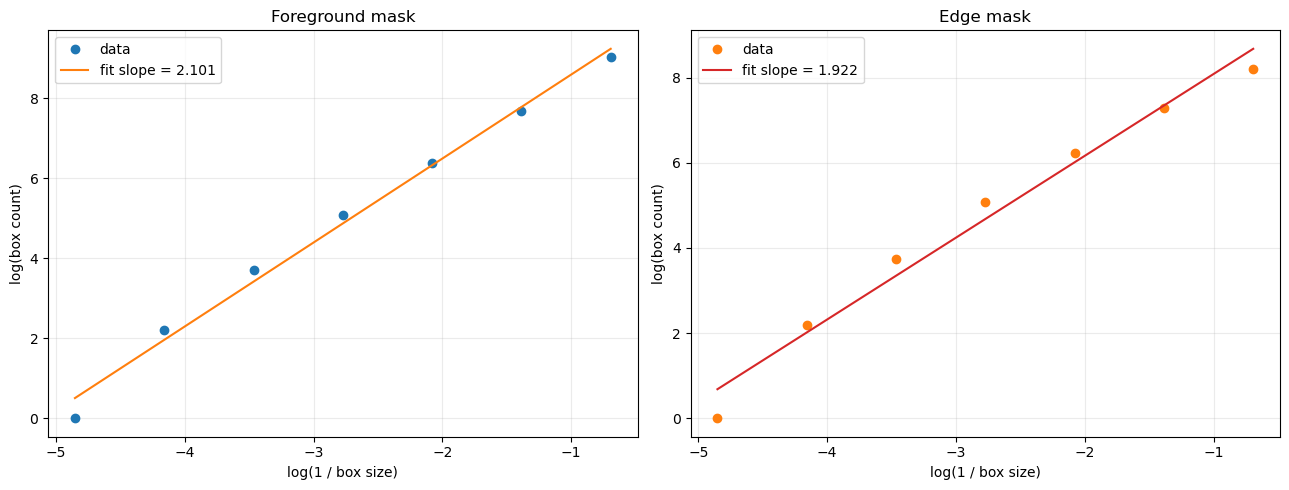

In [28]:
# Plot the log-log scaling for both masks
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Foreground fit
x_fg = np.log(1.0 / fg_sizes)
y_fg = np.log(fg_counts)
axes[0].plot(x_fg, y_fg, 'o', label='data')
axes[0].plot(x_fg, fg_dim * x_fg + fg_intercept, '-', label=f'fit slope = {fg_dim:.3f}')
axes[0].set_title('Foreground mask')
axes[0].set_xlabel('log(1 / box size)')
axes[0].set_ylabel('log(box count)')
axes[0].legend()
axes[0].grid(alpha=0.25)

# Edge fit
x_edge = np.log(1.0 / edge_sizes)
y_edge = np.log(edge_counts)
axes[1].plot(x_edge, y_edge, 'o', color='tab:orange', label='data')
axes[1].plot(x_edge, edge_dim * x_edge + edge_intercept, '-', color='tab:red', label=f'fit slope = {edge_dim:.3f}')
axes[1].set_title('Edge mask')
axes[1].set_xlabel('log(1 / box size)')
axes[1].set_ylabel('log(box count)')
axes[1].legend()
axes[1].grid(alpha=0.25)

plt.tight_layout()
plt.show()

### JC: The dimensionality is close to 2 but its slightly over with the foreground mask, I should probably try to increase the threshold and see if that gives me finer resolution. But first I wanna plot the box fitting.

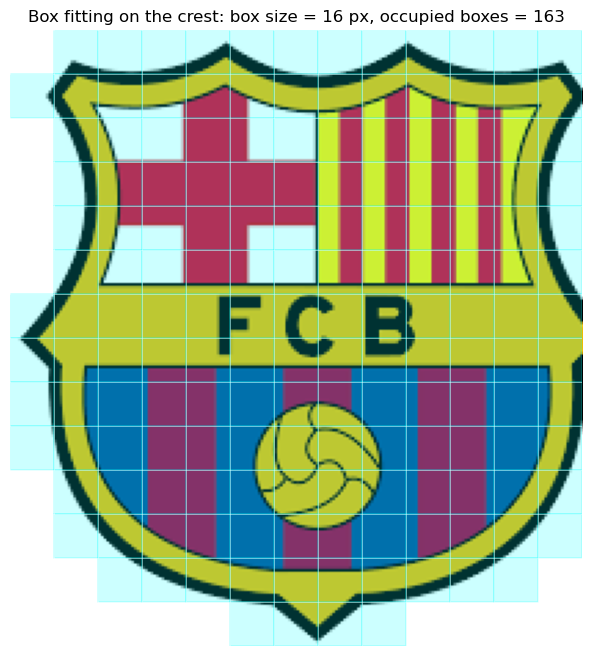

Box size used: 16 pixels
Occupied boxes counted: 163
Fraction occupied: 0.8956


In [29]:
import matplotlib.patches as patches

# Visualize one box-fitting step used in the box-counting algorithm
# Choose a representative box size from the fitted scales (middle scale works well).
if 'fg_sizes' not in globals() or len(fg_sizes) == 0:
    raise ValueError('Run the box-counting cells first so fg_sizes is available.')

box_size = int(fg_sizes[len(fg_sizes) // 2])
mask = foreground_crop
nrows, ncols = mask.shape
nrows_trim = (nrows // box_size) * box_size
ncols_trim = (ncols // box_size) * box_size
mask = mask[:nrows_trim, :ncols_trim]

# Build the occupied-box map and count boxes
box_map = np.add.reduceat(
    np.add.reduceat(mask, np.arange(0, mask.shape[0], box_size), axis=0),
    np.arange(0, mask.shape[1], box_size),
    axis=1,
 )
occupied = box_map > 0
num_boxes = int(np.count_nonzero(occupied))

fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(rgb_crop[:nrows_trim, :ncols_trim])

# Draw the box grid and highlight occupied boxes
for i in range(0, nrows_trim, box_size):
    ax.axhline(i - 0.5, color='white', lw=0.6, alpha=0.5)
for j in range(0, ncols_trim, box_size):
    ax.axvline(j - 0.5, color='white', lw=0.6, alpha=0.5)

for r in range(occupied.shape[0]):
    for c in range(occupied.shape[1]):
        if occupied[r, c]:
            rect = patches.Rectangle(
                (c * box_size - 0.5, r * box_size - 0.5),
                box_size,
                box_size,
                linewidth=1.2,
                edgecolor='cyan',
                facecolor='cyan',
                alpha=0.20,
            )
            ax.add_patch(rect)

ax.set_title(f'Box fitting on the crest: box size = {box_size} px, occupied boxes = {num_boxes}')
ax.set_xlim(-0.5, ncols_trim - 0.5)
ax.set_ylim(nrows_trim - 0.5, -0.5)
ax.set_aspect('equal', 'box')
ax.axis('off')
plt.show()

print(f'Box size used: {box_size} pixels')
print(f'Occupied boxes counted: {num_boxes}')
print(f'Fraction occupied: {num_boxes / occupied.size:.4f}')

### JC: This is a good visualization for now but i notice that there could be a lot more boxes. I should find a way to optimize the amount of boxes first. 

Shifted box-counting dimension estimate: 1.9085


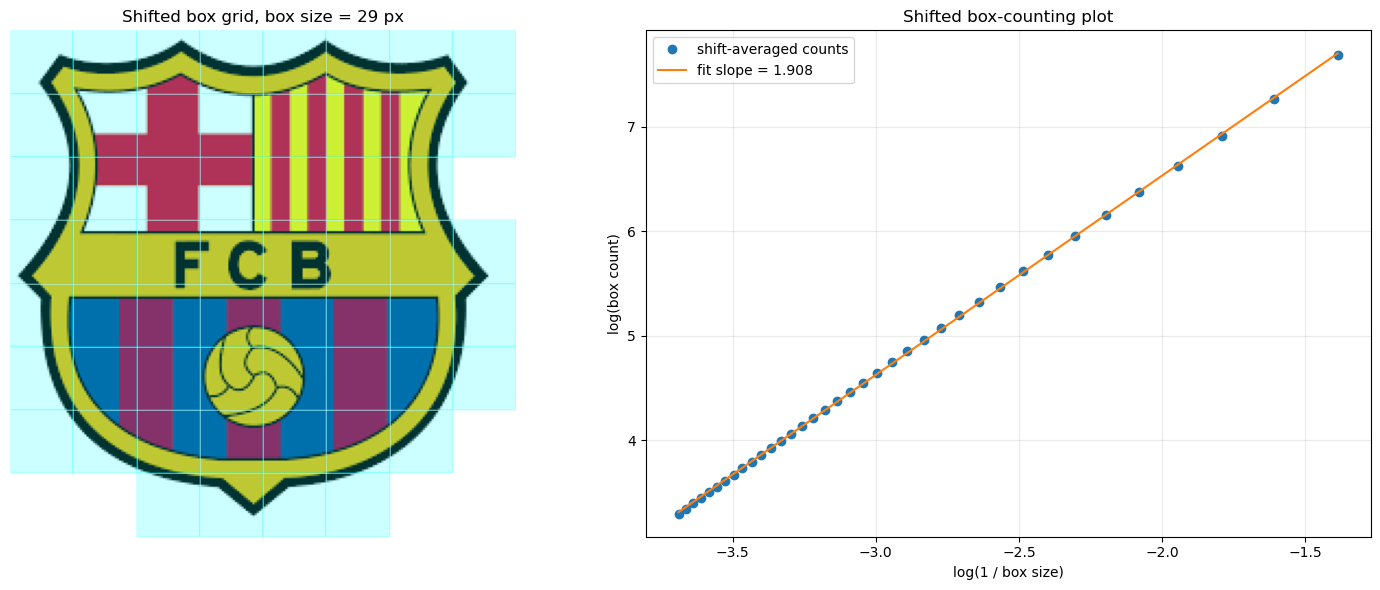

Box size used in visualization: 29 pixels
Occupied boxes in displayed shift: 58
Shift-averaged counts computed for 54 box sizes.


In [32]:
import matplotlib.patches as patches

def boxcount_shifted(Z, box_size):
    Z = np.asarray(Z, dtype=bool)
    counts = []

    for r0 in range(box_size):
        for c0 in range(box_size):
            Zshift = Z[r0:, c0:]
            if Zshift.shape[0] == 0 or Zshift.shape[1] == 0:
                continue

            pad_r = (-Zshift.shape[0]) % box_size
            pad_c = (-Zshift.shape[1]) % box_size

            Zpad = np.pad(Zshift, ((0, pad_r), (0, pad_c)),
                          mode='constant', constant_values=False)

            reshaped = Zpad.reshape(
                Zpad.shape[0] // box_size, box_size,
                Zpad.shape[1] // box_size, box_size
            )

            occupied = reshaped.any(axis=(1, 3))
            counts.append(np.count_nonzero(occupied))

    return np.mean(counts)

def estimate_box_dimension(mask, min_box=2, max_box=None, fit_min=4, fit_max=40):
    mask = np.asarray(mask, dtype=bool)

    if max_box is None:
        max_box = min(mask.shape) // 4

    box_sizes = np.arange(min_box, max_box + 1)
    counts = np.array([boxcount_shifted(mask, k) for k in box_sizes], dtype=float)

    valid = counts > 0
    box_sizes = box_sizes[valid]
    counts = counts[valid]

    fit = (box_sizes >= fit_min) & (box_sizes <= fit_max)

    x = np.log(1.0 / box_sizes[fit])
    y = np.log(counts[fit])

    slope, intercept = np.polyfit(x, y, 1)
    return box_sizes, counts, slope, intercept

# Use the foreground mask for the main box-counting estimate
mask = foreground_crop
box_sizes_shifted, counts_shifted, slope_shifted, intercept_shifted = estimate_box_dimension(
    mask, min_box=2, max_box=None, fit_min=4, fit_max=40
 )

print(f'Shifted box-counting dimension estimate: {slope_shifted:.4f}')

# Plot log(box count) vs log(1/box size)
fit_region = (box_sizes_shifted >= 4) & (box_sizes_shifted <= 40)
x = np.log(1.0 / box_sizes_shifted[fit_region])
y = np.log(counts_shifted[fit_region])

fig, (ax_img, ax) = plt.subplots(1, 2, figsize=(15, 6))

# Left panel: visualize one shifted box grid on the image
vis_box_size = int(box_sizes_shifted[len(box_sizes_shifted) // 2])
vis_r0, vis_c0 = 0, 0
Zshift = mask[vis_r0:, vis_c0:]
pad_r = (-Zshift.shape[0]) % vis_box_size
pad_c = (-Zshift.shape[1]) % vis_box_size
Zpad = np.pad(Zshift, ((0, pad_r), (0, pad_c)), mode='constant', constant_values=False)
reshaped = Zpad.reshape(
    Zpad.shape[0] // vis_box_size, vis_box_size,
    Zpad.shape[1] // vis_box_size, vis_box_size
 )
occupied = reshaped.any(axis=(1, 3))

ax_img.imshow(rgb_crop[:Zpad.shape[0], :Zpad.shape[1]])
for r in range(0, Zpad.shape[0], vis_box_size):
    ax_img.axhline(r - 0.5, color='white', lw=0.6, alpha=0.45)
for c in range(0, Zpad.shape[1], vis_box_size):
    ax_img.axvline(c - 0.5, color='white', lw=0.6, alpha=0.45)

for r in range(occupied.shape[0]):
    for c in range(occupied.shape[1]):
        if occupied[r, c]:
            rect = patches.Rectangle(
                (c * vis_box_size - 0.5, r * vis_box_size - 0.5),
                vis_box_size,
                vis_box_size,
                linewidth=1.1,
                edgecolor='cyan',
                facecolor='cyan',
                alpha=0.20,
            )
            ax_img.add_patch(rect)

ax_img.set_title(f'Shifted box grid, box size = {vis_box_size} px')
ax_img.set_xlim(-0.5, Zpad.shape[1] - 0.5)
ax_img.set_ylim(Zpad.shape[0] - 0.5, -0.5)
ax_img.set_aspect('equal', 'box')
ax_img.axis('off')

# Right panel: log-log box-counting plot
ax.plot(x, y, 'o', label='shift-averaged counts')
ax.plot(x, slope_shifted * x + intercept_shifted, '-', label=f'fit slope = {slope_shifted:.3f}')
ax.set_xlabel('log(1 / box size)')
ax.set_ylabel('log(box count)')
ax.set_title('Shifted box-counting plot')
ax.grid(alpha=0.25)
ax.legend()

plt.tight_layout()
plt.show()

print(f'Box size used in visualization: {vis_box_size} pixels')
print(f'Occupied boxes in displayed shift: {int(np.count_nonzero(occupied))}')
print(f'Shift-averaged counts computed for {len(box_sizes_shifted)} box sizes.')

### JC: Still not what i wanted so im gonna ask again to decrease the size of each box.

High-resolution shifted box-counting dimension estimate: 1.9085


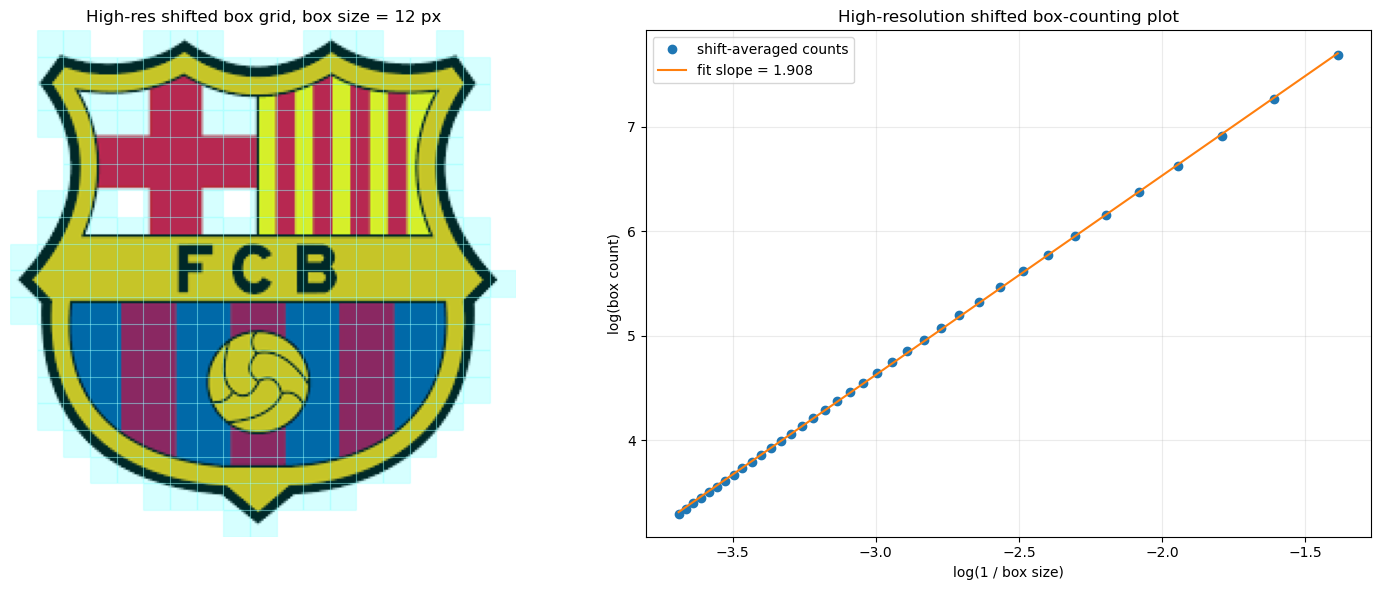

Box size used in high-res visualization: 12 pixels
Occupied boxes in displayed shift: 278
Shift-averaged counts computed for 54 box sizes.


In [33]:
import matplotlib.patches as patches

# Higher-resolution version: use a smaller box size for the displayed grid
# This keeps the same shifted box-counting algorithm, but zooms in the box fitting.
if 'boxcount_shifted' not in globals() or 'estimate_box_dimension' not in globals():
    raise ValueError('Run the shifted box-counting cell first so the functions are available.')

mask = foreground_crop

# Recompute counts and fit using the same algorithm as above
box_sizes_shifted_hr, counts_shifted_hr, slope_shifted_hr, intercept_shifted_hr = estimate_box_dimension(
    mask, min_box=2, max_box=None, fit_min=4, fit_max=40
 )

print(f'High-resolution shifted box-counting dimension estimate: {slope_shifted_hr:.4f}')

# Plot the log-log result and the finer box overlay
fit_region_hr = (box_sizes_shifted_hr >= 4) & (box_sizes_shifted_hr <= 40)
x_hr = np.log(1.0 / box_sizes_shifted_hr[fit_region_hr])
y_hr = np.log(counts_shifted_hr[fit_region_hr])

fig, (ax_img, ax) = plt.subplots(1, 2, figsize=(15, 6))

# Use a smaller box size for a denser grid on the image
vis_box_size_hr = max(2, int(np.percentile(box_sizes_shifted_hr, 20)))
vis_r0_hr, vis_c0_hr = 0, 0
Zshift_hr = mask[vis_r0_hr:, vis_c0_hr:]
pad_r_hr = (-Zshift_hr.shape[0]) % vis_box_size_hr
pad_c_hr = (-Zshift_hr.shape[1]) % vis_box_size_hr
Zpad_hr = np.pad(Zshift_hr, ((0, pad_r_hr), (0, pad_c_hr)), mode='constant', constant_values=False)
reshaped_hr = Zpad_hr.reshape(
    Zpad_hr.shape[0] // vis_box_size_hr, vis_box_size_hr,
    Zpad_hr.shape[1] // vis_box_size_hr, vis_box_size_hr
 )
occupied_hr = reshaped_hr.any(axis=(1, 3))

ax_img.imshow(rgb_crop[:Zpad_hr.shape[0], :Zpad_hr.shape[1]])
for r in range(0, Zpad_hr.shape[0], vis_box_size_hr):
    ax_img.axhline(r - 0.5, color='white', lw=0.45, alpha=0.45)
for c in range(0, Zpad_hr.shape[1], vis_box_size_hr):
    ax_img.axvline(c - 0.5, color='white', lw=0.45, alpha=0.45)

for r in range(occupied_hr.shape[0]):
    for c in range(occupied_hr.shape[1]):
        if occupied_hr[r, c]:
            rect = patches.Rectangle(
                (c * vis_box_size_hr - 0.5, r * vis_box_size_hr - 0.5),
                vis_box_size_hr,
                vis_box_size_hr,
                linewidth=0.9,
                edgecolor='cyan',
                facecolor='cyan',
                alpha=0.16,
            )
            ax_img.add_patch(rect)

ax_img.set_title(f'High-res shifted box grid, box size = {vis_box_size_hr} px')
ax_img.set_xlim(-0.5, Zpad_hr.shape[1] - 0.5)
ax_img.set_ylim(Zpad_hr.shape[0] - 0.5, -0.5)
ax_img.set_aspect('equal', 'box')
ax_img.axis('off')

ax.plot(x_hr, y_hr, 'o', label='shift-averaged counts')
ax.plot(x_hr, slope_shifted_hr * x_hr + intercept_shifted_hr, '-', label=f'fit slope = {slope_shifted_hr:.3f}')
ax.set_xlabel('log(1 / box size)')
ax.set_ylabel('log(box count)')
ax.set_title('High-resolution shifted box-counting plot')
ax.grid(alpha=0.25)
ax.legend()

plt.tight_layout()
plt.show()

print(f'Box size used in high-res visualization: {vis_box_size_hr} pixels')
print(f'Occupied boxes in displayed shift: {int(np.count_nonzero(occupied_hr))}')
print(f'Shift-averaged counts computed for {len(box_sizes_shifted_hr)} box sizes.')

### JC: MORE BOXES

Smaller-box shifted box-counting dimension estimate: 1.9085


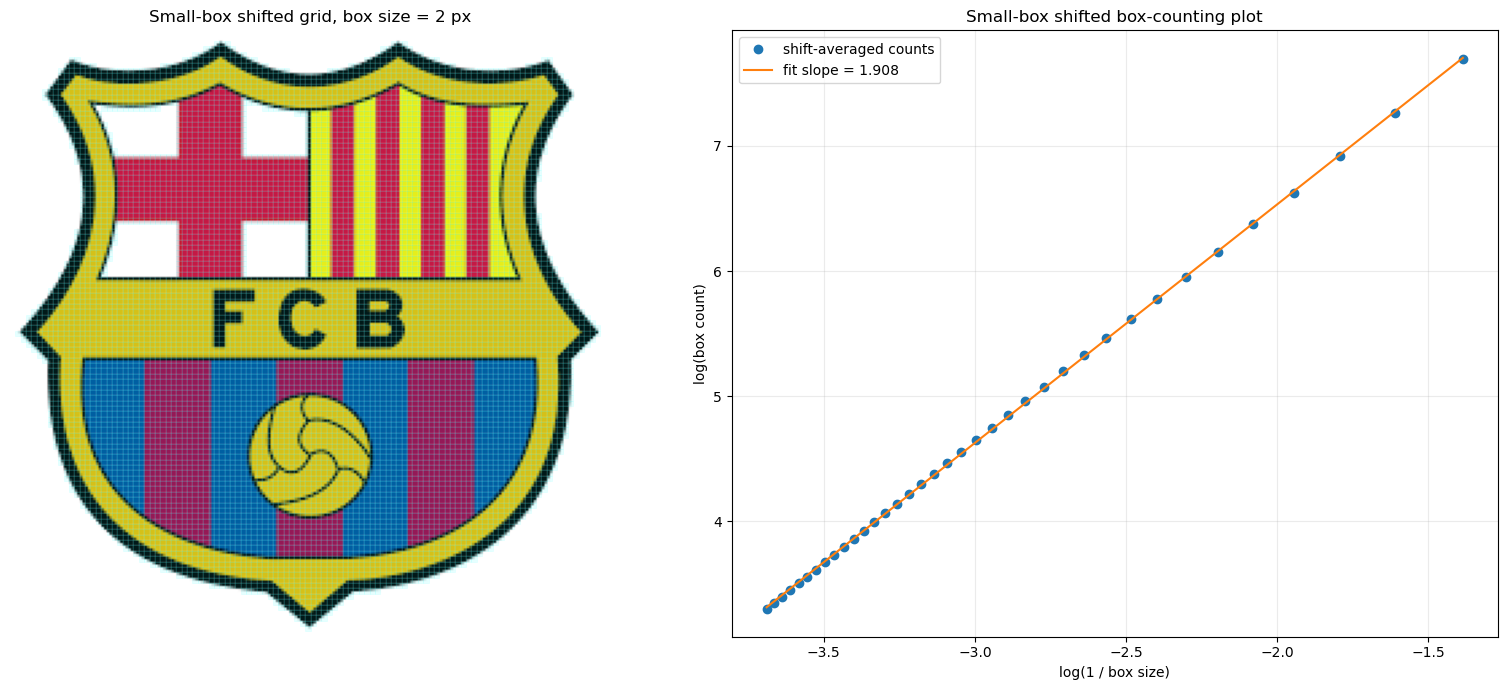

Box size used in small-box visualization: 2 pixels
Occupied boxes in displayed shift: 8433
Shift-averaged counts computed for 54 box sizes.


In [34]:
import matplotlib.patches as patches

# Even denser version: force the smallest practical displayed boxes
# This keeps the same shifted box-counting algorithm but shows more, smaller squares.
if 'boxcount_shifted' not in globals() or 'estimate_box_dimension' not in globals():
    raise ValueError('Run the shifted box-counting cell first so the functions are available.')

mask = foreground_crop

# Reuse the same shifted counts/fitting approach
box_sizes_shifted_sm, counts_shifted_sm, slope_shifted_sm, intercept_shifted_sm = estimate_box_dimension(
    mask, min_box=2, max_box=None, fit_min=4, fit_max=40
 )

print(f'Smaller-box shifted box-counting dimension estimate: {slope_shifted_sm:.4f}')

fit_region_sm = (box_sizes_shifted_sm >= 4) & (box_sizes_shifted_sm <= 40)
x_sm = np.log(1.0 / box_sizes_shifted_sm[fit_region_sm])
y_sm = np.log(counts_shifted_sm[fit_region_sm])

fig, (ax_img, ax) = plt.subplots(1, 2, figsize=(16, 7))

# Force the smallest box size for the display grid
vis_box_size_sm = 2
vis_r0_sm, vis_c0_sm = 0, 0
Zshift_sm = mask[vis_r0_sm:, vis_c0_sm:]
pad_r_sm = (-Zshift_sm.shape[0]) % vis_box_size_sm
pad_c_sm = (-Zshift_sm.shape[1]) % vis_box_size_sm
Zpad_sm = np.pad(Zshift_sm, ((0, pad_r_sm), (0, pad_c_sm)), mode='constant', constant_values=False)
reshaped_sm = Zpad_sm.reshape(
    Zpad_sm.shape[0] // vis_box_size_sm, vis_box_size_sm,
    Zpad_sm.shape[1] // vis_box_size_sm, vis_box_size_sm
 )
occupied_sm = reshaped_sm.any(axis=(1, 3))

ax_img.imshow(rgb_crop[:Zpad_sm.shape[0], :Zpad_sm.shape[1]])
for r in range(0, Zpad_sm.shape[0], vis_box_size_sm):
    ax_img.axhline(r - 0.5, color='white', lw=0.3, alpha=0.35)
for c in range(0, Zpad_sm.shape[1], vis_box_size_sm):
    ax_img.axvline(c - 0.5, color='white', lw=0.3, alpha=0.35)

for r in range(occupied_sm.shape[0]):
    for c in range(occupied_sm.shape[1]):
        if occupied_sm[r, c]:
            rect = patches.Rectangle(
                (c * vis_box_size_sm - 0.5, r * vis_box_size_sm - 0.5),
                vis_box_size_sm,
                vis_box_size_sm,
                linewidth=0.5,
                edgecolor='cyan',
                facecolor='cyan',
                alpha=0.10,
            )
            ax_img.add_patch(rect)

ax_img.set_title(f'Small-box shifted grid, box size = {vis_box_size_sm} px')
ax_img.set_xlim(-0.5, Zpad_sm.shape[1] - 0.5)
ax_img.set_ylim(Zpad_sm.shape[0] - 0.5, -0.5)
ax_img.set_aspect('equal', 'box')
ax_img.axis('off')

ax.plot(x_sm, y_sm, 'o', label='shift-averaged counts')
ax.plot(x_sm, slope_shifted_sm * x_sm + intercept_shifted_sm, '-', label=f'fit slope = {slope_shifted_sm:.3f}')
ax.set_xlabel('log(1 / box size)')
ax.set_ylabel('log(box count)')
ax.set_title('Small-box shifted box-counting plot')
ax.grid(alpha=0.25)
ax.legend()

plt.tight_layout()
plt.show()

print(f'Box size used in small-box visualization: {vis_box_size_sm} pixels')
print(f'Occupied boxes in displayed shift: {int(np.count_nonzero(occupied_sm))}')
print(f'Shift-averaged counts computed for {len(box_sizes_shifted_sm)} box sizes.')

### JC: now there are more boxes, why isnt the dimensionality increasing? I'm gonna explore that.

Recalculated small-box dimension estimate: 1.9163850532058981


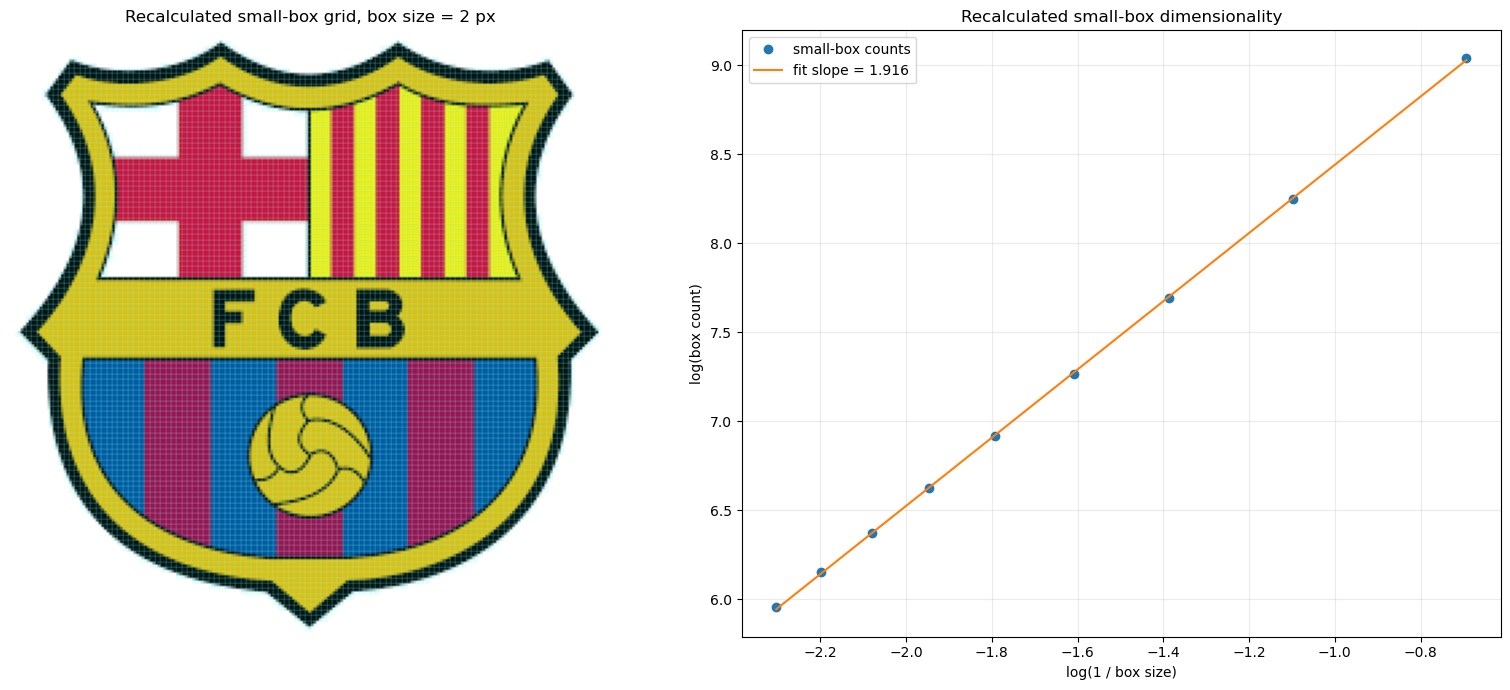

Box size used: 2 pixels
Occupied boxes in displayed shift: 8433
Counts used in fit: 9


In [45]:
# Recalculate the dimensionality using the same small-box regime
# The box-counting dimension is still a slope from multiple box sizes,
# but this time we emphasize the smaller sizes used in the denser grid.
if 'boxcount_shifted' not in globals() or 'estimate_box_dimension' not in globals():
    raise ValueError('Run the shifted box-counting cells first so the functions are available.')

mask = foreground_crop

# Focus the fit more tightly on small boxes so the recalculation reflects the denser scale
box_sizes_recalc, counts_recalc, slope_recalc, intercept_recalc = estimate_box_dimension(
    mask, min_box=2, max_box=24, fit_min=2, fit_max=10
 )

print(f'Recalculated small-box dimension estimate: {slope_recalc:.16f}')

# Visualize the same small-box regime and the updated log-log fit
fit_region_recalc = (box_sizes_recalc >= 2) & (box_sizes_recalc <= 10)
x_recalc = np.log(1.0 / box_sizes_recalc[fit_region_recalc])
y_recalc = np.log(counts_recalc[fit_region_recalc])

vis_box_size_recalc = 2
vis_r0_recalc, vis_c0_recalc = 0, 0
Zshift_recalc = mask[vis_r0_recalc:, vis_c0_recalc:]
pad_r_recalc = (-Zshift_recalc.shape[0]) % vis_box_size_recalc
pad_c_recalc = (-Zshift_recalc.shape[1]) % vis_box_size_recalc
Zpad_recalc = np.pad(Zshift_recalc, ((0, pad_r_recalc), (0, pad_c_recalc)), mode='constant', constant_values=False)
reshaped_recalc = Zpad_recalc.reshape(
    Zpad_recalc.shape[0] // vis_box_size_recalc, vis_box_size_recalc,
    Zpad_recalc.shape[1] // vis_box_size_recalc, vis_box_size_recalc
 )
occupied_recalc = reshaped_recalc.any(axis=(1, 3))

fig, (ax_img, ax) = plt.subplots(1, 2, figsize=(16, 7))
ax_img.imshow(rgb_crop[:Zpad_recalc.shape[0], :Zpad_recalc.shape[1]])

for r in range(0, Zpad_recalc.shape[0], vis_box_size_recalc):
    ax_img.axhline(r - 0.5, color='white', lw=0.3, alpha=0.35)
for c in range(0, Zpad_recalc.shape[1], vis_box_size_recalc):
    ax_img.axvline(c - 0.5, color='white', lw=0.3, alpha=0.35)

for r in range(occupied_recalc.shape[0]):
    for c in range(occupied_recalc.shape[1]):
        if occupied_recalc[r, c]:
            rect = patches.Rectangle(
                (c * vis_box_size_recalc - 0.5, r * vis_box_size_recalc - 0.5),
                vis_box_size_recalc,
                vis_box_size_recalc,
                linewidth=0.45,
                edgecolor='cyan',
                facecolor='cyan',
                alpha=0.09,
            )
            ax_img.add_patch(rect)

ax_img.set_title(f'Recalculated small-box grid, box size = {vis_box_size_recalc} px')
ax_img.set_xlim(-0.5, Zpad_recalc.shape[1] - 0.5)
ax_img.set_ylim(Zpad_recalc.shape[0] - 0.5, -0.5)
ax_img.set_aspect('equal', 'box')
ax_img.axis('off')

ax.plot(x_recalc, y_recalc, 'o', label='small-box counts')
ax.plot(x_recalc, slope_recalc * x_recalc + intercept_recalc, '-', label=f'fit slope = {slope_recalc:.3f}')
ax.set_xlabel('log(1 / box size)')
ax.set_ylabel('log(box count)')
ax.set_title('Recalculated small-box dimensionality')
ax.grid(alpha=0.25)
ax.legend()

plt.tight_layout()
plt.show()

print(f'Box size used: {vis_box_size_recalc} pixels')
print(f'Occupied boxes in displayed shift: {int(np.count_nonzero(occupied_recalc))}')
print(f'Counts used in fit: {len(box_sizes_recalc[fit_region_recalc])}')

Full-range box-counting dimension estimate: 1.9169508269084357
Total box sizes used in computation: 54


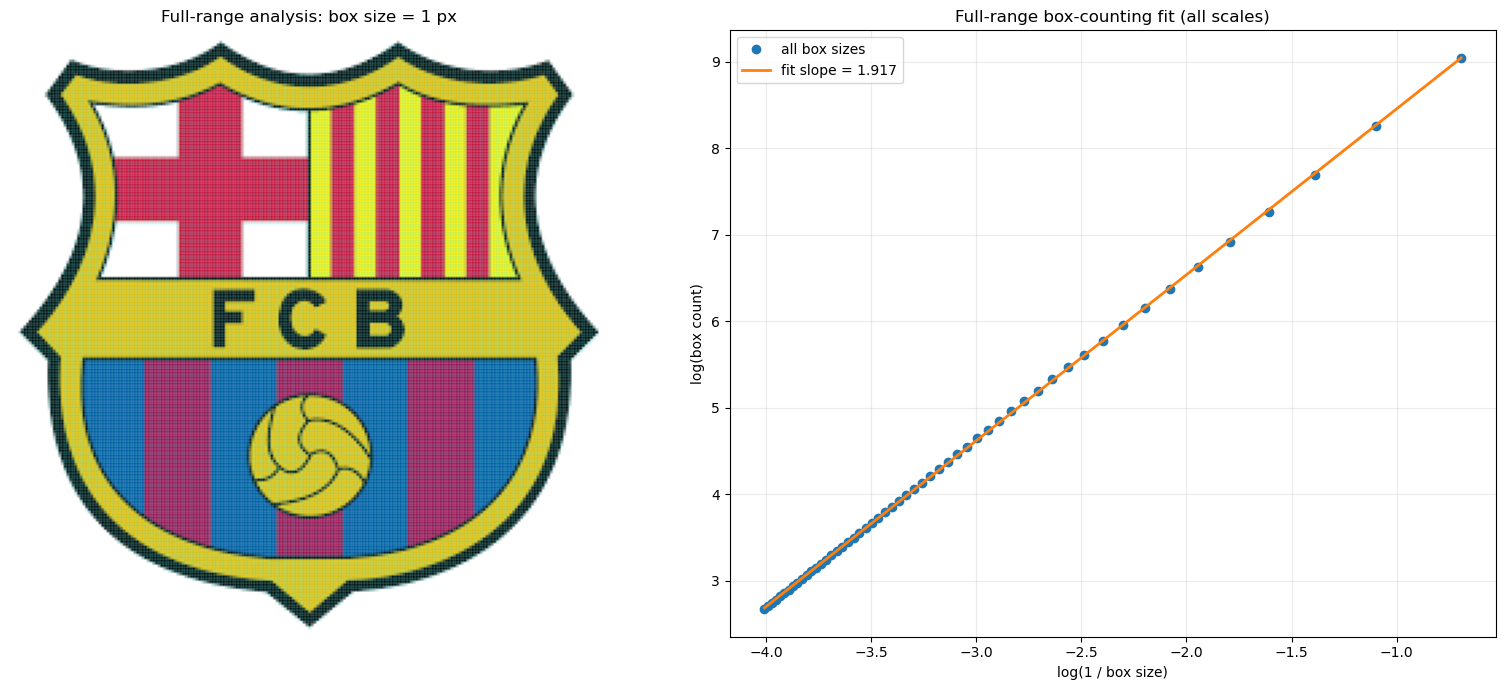

Box size visualized: 1 pixels
Occupied boxes in displayed shift: 33108
All box sizes used in fit: 54


In [46]:
# Use all computed box sizes in the fit to get the full-range dimensionality
# This expands the fit window to include all available scales.
if 'boxcount_shifted' not in globals() or 'estimate_box_dimension' not in globals():
    raise ValueError('Run the shifted box-counting cells first so the functions are available.')

mask = foreground_crop

# Compute dimension using the full range of box sizes available
box_sizes_all, counts_all, slope_all, intercept_all = estimate_box_dimension(
    mask, min_box=2, max_box=None, fit_min=2, fit_max=2000
 )

print(f'Full-range box-counting dimension estimate: {slope_all:.16f}')
print(f'Total box sizes used in computation: {len(box_sizes_all)}')

# Use all valid sizes in the fit
fit_region_all = (counts_all > 0)
x_all = np.log(1.0 / box_sizes_all[fit_region_all])
y_all = np.log(counts_all[fit_region_all])

vis_box_size_all = 1
vis_r0_all, vis_c0_all = 0, 0
Zshift_all = mask[vis_r0_all:, vis_c0_all:]
pad_r_all = (-Zshift_all.shape[0]) % vis_box_size_all
pad_c_all = (-Zshift_all.shape[1]) % vis_box_size_all
Zpad_all = np.pad(Zshift_all, ((0, pad_r_all), (0, pad_c_all)), mode='constant', constant_values=False)
reshaped_all = Zpad_all.reshape(
    Zpad_all.shape[0] // vis_box_size_all, vis_box_size_all,
    Zpad_all.shape[1] // vis_box_size_all, vis_box_size_all
 )
occupied_all = reshaped_all.any(axis=(1, 3))

fig, (ax_img, ax) = plt.subplots(1, 2, figsize=(16, 7))
ax_img.imshow(rgb_crop[:Zpad_all.shape[0], :Zpad_all.shape[1]])

for r in range(0, Zpad_all.shape[0], vis_box_size_all):
    ax_img.axhline(r - 0.5, color='white', lw=0.3, alpha=0.35)
for c in range(0, Zpad_all.shape[1], vis_box_size_all):
    ax_img.axvline(c - 0.5, color='white', lw=0.3, alpha=0.35)

for r in range(occupied_all.shape[0]):
    for c in range(occupied_all.shape[1]):
        if occupied_all[r, c]:
            rect = patches.Rectangle(
                (c * vis_box_size_all - 0.5, r * vis_box_size_all - 0.5),
                vis_box_size_all,
                vis_box_size_all,
                linewidth=0.4,
                edgecolor='cyan',
                facecolor='cyan',
                alpha=0.08,
            )
            ax_img.add_patch(rect)

ax_img.set_title(f'Full-range analysis: box size = {vis_box_size_all} px')
ax_img.set_xlim(-0.5, Zpad_all.shape[1] - 0.5)
ax_img.set_ylim(Zpad_all.shape[0] - 0.5, -0.5)
ax_img.set_aspect('equal', 'box')
ax_img.axis('off')

ax.plot(x_all, y_all, 'o', label='all box sizes')
ax.plot(x_all, slope_all * x_all + intercept_all, '-', linewidth=2, label=f'fit slope = {slope_all:.3f}')
ax.set_xlabel('log(1 / box size)')
ax.set_ylabel('log(box count)')
ax.set_title('Full-range box-counting fit (all scales)')
ax.grid(alpha=0.25)
ax.legend()

plt.tight_layout()
plt.show()

print(f'Box size visualized: {vis_box_size_all} pixels')
print(f'Occupied boxes in displayed shift: {int(np.count_nonzero(occupied_all))}')
print(f'All box sizes used in fit: {len(box_sizes_all[fit_region_all])}')

### JC: I think this is the best I can get the resolution for it.

In [ ]:
1.9169508269084357
1.9163850532058981
